# 01 — Data Exploration

This notebook explores the ingested financial document corpus.

**Run ingestion first:**
```bash
python scripts/ingest_pipeline.py --use-sample-data
```

In [3]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import chromadb

client = chromadb.PersistentClient(path='../data/chroma')
collection = client.get_or_create_collection('financial_docs')
result = collection.get(include=['documents', 'metadatas'])
df = pd.DataFrame(result['metadatas'])
df['char_count'] = [len(d) for d in result['documents']]
print(f'Total chunks: {len(df)}')
df.head()

Total chunks: 5


,chunk_index,filing_type,year,source,section,ticker,char_count
0,0,10-K,2023,sample/AAPL_10-K_2023.txt,General,AAPL,1553
1,0,10-K,2023,sample/MSFT_10-K_2023.txt,General,MSFT,810
2,1,10-K,2023,sample/MSFT_10-K_2023.txt,ITEM 7. MANAGEMENT'S DISCUSSION AND ANALYSIS\n...,MSFT,557
3,0,10-K,2024,sample/NVDA_10-K_2024.txt,General,NVDA,969
4,1,10-K,2024,sample/NVDA_10-K_2024.txt,ITEM 7. MANAGEMENT'S DISCUSSION AND ANALYSIS\n...,NVDA,559


AttributeError: Rectangle.set() got an unexpected keyword argument 'title'

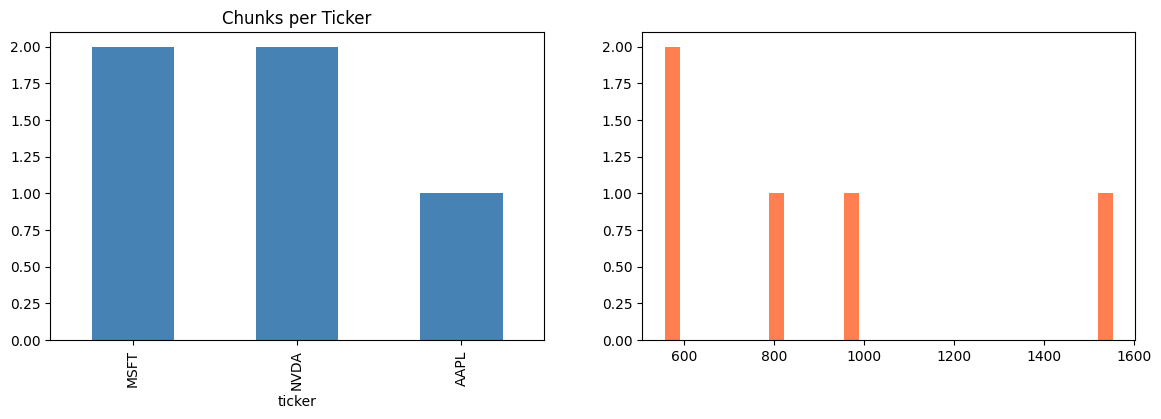

In [4]:
# Distribution of chunks by ticker
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['ticker'].value_counts().plot(kind='bar', ax=axes[0], title='Chunks per Ticker', color='steelblue')
df['char_count'].hist(bins=30, ax=axes[1], color='coral', title='Chunk Size Distribution (chars)')
axes[1].axvline(df['char_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["char_count"].mean():.0f}')
axes[1].legend()
plt.tight_layout()
plt.savefig('../results/corpus_overview.png', dpi=150)
plt.show()
print(df.groupby('ticker')[['char_count']].describe())

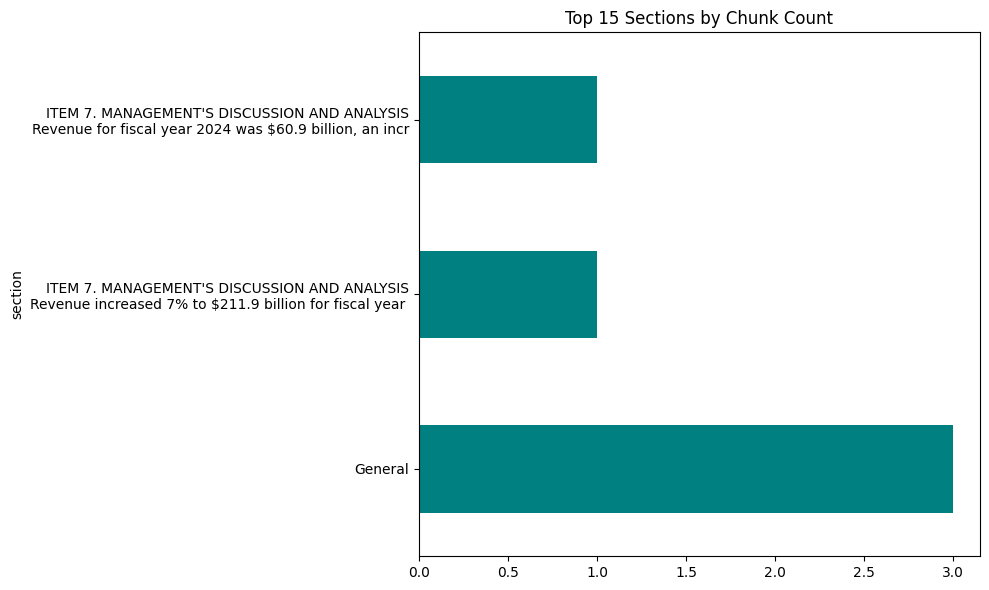

In [5]:
# Section coverage analysis
section_counts = df['section'].value_counts().head(15)
section_counts.plot(kind='barh', figsize=(10, 6), title='Top 15 Sections by Chunk Count', color='teal')
plt.tight_layout()
plt.savefig('../results/section_coverage.png', dpi=150)
plt.show()